# Comparação de Algoritmos Genéticos  e Fuzzy no Controle PID
Este notebook apresenta uma comparação entre duas técnicas (algoritmos genéticos e lógica fuzzy) para ajuste dos parâmetros de um controlador PID aplicado a um sistema de segunda ordem.

In [3]:
# Incluindo o comando de instalação para o pacote scikit-fuzzy
!pip install -U scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 10.3 MB/s eta 0:00:00


In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import skfuzzy as fuzz

In [15]:
# Modelo do sistema de segunda ordem
def second_order_system(y, t, u, K, tau, zeta):
    dydt = [y[1], -(2 * zeta / tau) * y[1] - (1 / tau**2) * y[0] + (K / tau**2) * u]
    return dydt


# Controlador PID
def pid_control(setpoint, process_output, prev_error, integral_error, dt, Kp, Ki, Kd):
    error = setpoint - process_output
    integral_error += error * dt
    derivative_error = (error - prev_error) / dt
    u = Kp * error + Ki * integral_error + Kd * derivative_error
    return u, error, integral_error


# Função para calcular o erro de cada controlador
def calculate_error(Kp, Ki, Kd, setpoint=1.0, time=np.linspace(0, 10, 1000), K=1.5, tau=2.0, zeta=0.7):
    y0 = [0, 0]  # Condições iniciais
    prev_error = 0
    integral_error = 0
    dt = time[1] - time[0]
    total_error = 0

    for t in time:
        u, prev_error, integral_error = pid_control(setpoint, y0[0], prev_error, integral_error, dt, Kp, Ki, Kd)
        y0 = odeint(second_order_system, y0, [t, t + dt], args=(u, K, tau, zeta))[-1]
        total_error += (setpoint - y0[0])**2

    return total_error

In [6]:
# Algoritmo Genético
def genetic_algorithm(generations, population_size):
    def init_population(size):
        return [{'Kp': random.uniform(0, 5), 'Ki': random.uniform(0, 5), 'Kd': random.uniform(0, 5)} for _ in range(size)]

    def crossover(parent1, parent2):
        return {'Kp': (parent1['Kp'] + parent2['Kp']) / 2, 'Ki': (parent1['Ki'] + parent2['Ki']) / 2, 'Kd': (parent1['Kd'] + parent2['Kd']) / 2}

    def mutate(individual, mutation_rate=0.1):
        if random.random() < mutation_rate:
            individual['Kp'] += random.uniform(-0.1, 0.1)
        if random.random() < mutation_rate:
            individual['Ki'] += random.uniform(-0.1, 0.1)
        if random.random() < mutation_rate:
            individual['Kd'] += random.uniform(-0.1, 0.1)
        return individual

    population = init_population(population_size)
    best_solution = None
    best_fitness = float('inf')

    for generation in range(generations):
        new_population = []
        for _ in range(population_size // 2):
            parent1, parent2 = random.sample(population, 2)
            child1 = mutate(crossover(parent1, parent2))
            child2 = mutate(crossover(parent1, parent2))
            new_population.extend([child1, child2])

        population = sorted(new_population, key=lambda ind: calculate_error(**ind))
        best_solution = population[0]
        best_fitness = calculate_error(**best_solution)

    return best_solution

In [23]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Variáveis de entrada (Erro e Variação do Erro)
error = ctrl.Antecedent(np.linspace(-1, 1, 100), 'error')
d_error = ctrl.Antecedent(np.linspace(-1, 1, 100), 'd_error')

# Variáveis de saída (Kp, Ki, Kd)
Kp = ctrl.Consequent(np.linspace(0, 10, 100), 'Kp')
Ki = ctrl.Consequent(np.linspace(0, 5, 100), 'Ki')
Kd = ctrl.Consequent(np.linspace(0, 5, 100), 'Kd')

# Funções de pertinência para Erro e Variação do Erro
error['negative'] = fuzz.trimf(error.universe, [-1, -1, 0])
error['zero'] = fuzz.trimf(error.universe, [-1, 0, 1])
error['positive'] = fuzz.trimf(error.universe, [0, 1, 1])

d_error['negative'] = fuzz.trimf(d_error.universe, [-1, -1, 0])
d_error['zero'] = fuzz.trimf(d_error.universe, [-1, 0, 1])
d_error['positive'] = fuzz.trimf(d_error.universe, [0, 1, 1])

# Funções de pertinência para Kp, Ki, Kd
Kp['low'] = fuzz.trimf(Kp.universe, [0, 0, 5])
Kp['medium'] = fuzz.trimf(Kp.universe, [0, 5, 10])
Kp['high'] = fuzz.trimf(Kp.universe, [5, 10, 10])

Ki['low'] = fuzz.trimf(Ki.universe, [0, 0, 2.5])
Ki['medium'] = fuzz.trimf(Ki.universe, [0, 2.5, 5])
Ki['high'] = fuzz.trimf(Ki.universe, [2.5, 5, 5])

Kd['low'] = fuzz.trimf(Kd.universe, [0, 0, 2.5])
Kd['medium'] = fuzz.trimf(Kd.universe, [0, 2.5, 5])
Kd['high'] = fuzz.trimf(Kd.universe, [2.5, 5, 5])

# Regras Fuzzy
rules = [
    ctrl.Rule(error['negative'] & d_error['negative'], (Kp['high'], Ki['low'], Kd['medium'])),
    ctrl.Rule(error['negative'] & d_error['zero'], (Kp['medium'], Ki['medium'], Kd['low'])),
    ctrl.Rule(error['negative'] & d_error['positive'], (Kp['low'], Ki['medium'], Kd['low'])),
    ctrl.Rule(error['zero'] & d_error['negative'], (Kp['medium'], Ki['medium'], Kd['medium'])),
    ctrl.Rule(error['zero'] & d_error['zero'], (Kp['medium'], Ki['medium'], Kd['medium'])),
    ctrl.Rule(error['zero'] & d_error['positive'], (Kp['low'], Ki['low'], Kd['low'])),
    ctrl.Rule(error['positive'] & d_error['negative'], (Kp['low'], Ki['high'], Kd['medium'])),
    ctrl.Rule(error['positive'] & d_error['zero'], (Kp['low'], Ki['medium'], Kd['medium'])),
    ctrl.Rule(error['positive'] & d_error['positive'], (Kp['low'], Ki['low'], Kd['low'])),
]

# Sistema de controle Fuzzy
pid_ctrl = ctrl.ControlSystem(rules)
pid_simulation = ctrl.ControlSystemSimulation(pid_ctrl)

# Função para calcular os valores de Kp, Ki, Kd
def fuzzy_pid_control(error_value, d_error_value):
    """
    Calcula os valores de Kp, Ki e Kd com base na lógica fuzzy.

    :param error_value: Valor atual do erro.
    :param d_error_value: Variação do erro.
    :return: Valores ajustados de Kp, Ki e Kd.
    """
    pid_simulation.input['error'] = error_value
    pid_simulation.input['d_error'] = d_error_value
    pid_simulation.compute()

    Kp_value = pid_simulation.output['Kp']
    Ki_value = pid_simulation.output['Ki']
    Kd_value = pid_simulation.output['Kd']

    return Kp_value, Ki_value, Kd_value

In [28]:
# Função para simular e plotar os gráficos de cada controlador
def plot_responses(time, setpoint, Kp_ga, Ki_ga, Kd_ga, Kp_fuzzy, Ki_fuzzy, Kd_fuzzy, K=1.5, tau=2.0, zeta=0.7):
    y0_ga = [0, 0]
    y0_fuzzy = [0, 0]
    output_ga = []
    output_fuzzy = []
    prev_error_ga = 0
    integral_error_ga = 0
    prev_error_fuzzy = 0
    integral_error_fuzzy = 0
    dt = time[1] - time[0]

    for t in time:
        # GA Controlador
        u_ga, prev_error_ga, integral_error_ga = pid_control(setpoint, y0_ga[0], prev_error_ga, integral_error_ga, dt, Kp_ga, Ki_ga, Kd_ga)
        y0_ga = odeint(second_order_system, y0_ga, [t, t + dt], args=(u_ga, K, tau, zeta))[-1]
        output_ga.append(y0_ga[0])

        # Fuzzy Controlador
        error_fuzzy = setpoint - y0_fuzzy[0]
        d_error_fuzzy = (error_fuzzy - prev_error_fuzzy) / dt
        kp_fuzzy, ki_fuzzy, kd_fuzzy = fuzzy_pid_control(error_fuzzy, d_error_fuzzy)
        u_fuzzy, prev_error_fuzzy, integral_error_fuzzy = pid_control(setpoint, y0_fuzzy[0], prev_error_fuzzy, integral_error_fuzzy, dt, kp_fuzzy, ki_fuzzy, kd_fuzzy)
        y0_fuzzy = odeint(second_order_system, y0_fuzzy, [t, t + dt], args=(u_fuzzy, K, tau, zeta))[-1]
        output_fuzzy.append(y0_fuzzy[0])

    # Plotando os resultados
    plt.figure(figsize=(12, 6))
    plt.plot(time, output_ga, label='GA PID Output', color='blue')
    plt.plot(time, output_fuzzy, label='Fuzzy PID Output', color='green')
    plt.axhline(setpoint, color='red', linestyle='--', label='Setpoint')
    plt.title('Respostas dos Controladores PID Ajustados')
    plt.xlabel('Tempo (s)')
    plt.ylabel('Saída')
    plt.legend()
    plt.grid()
    plt.show()

    return output_ga, output_fuzzy


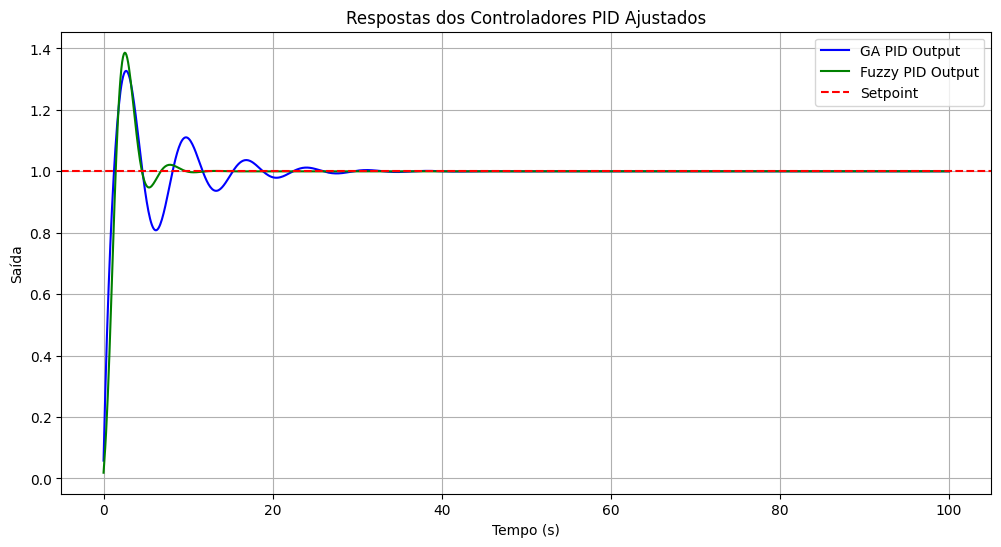

In [30]:
# Configuração inicial
time = np.linspace(0, 100, 1000)
setpoint = 1.0

# Ajuste pelo GA
best_pid_ga = genetic_algorithm(generations=50, population_size=20)
Kp_ga, Ki_ga, Kd_ga = best_pid_ga['Kp'], best_pid_ga['Ki'], best_pid_ga['Kd']

# Ajuste pelo Fuzzy
Kp_fuzzy, Ki_fuzzy, Kd_fuzzy = fuzzy_pid_control(0.1, 0.01)

# Plotando as respostas
output_ga, output_fuzzy = plot_responses(time, setpoint, Kp_ga, Ki_ga, Kd_ga, Kp_fuzzy, Ki_fuzzy, Kd_fuzzy)

In [26]:
def calculate_overshoot(output, y_final):
    """
    Calcula o overshoot de um sistema.

    :param output: Lista ou array com os valores da saída do sistema.
    :param y_final: Valor final esperado da saída do sistema (setpoint).
    :return: Overshoot em porcentagem.
    """
    y_max = max(output)
    if y_max > y_final:
        return ((y_max - y_final) / y_final) * 100
    return 0  # Se não houver overshoot

In [27]:
def calculate_settling_time(output, time, y_final, tolerance=0.02):
    """
    Calcula o tempo de estabilização do sistema.

    :param output: Lista ou array com os valores da saída do sistema.
    :param time: Lista ou array com os instantes de tempo correspondentes.
    :param y_final: Valor final esperado da saída do sistema (setpoint).
    :param tolerance: Tolerância em relação ao valor final (default: 0.02 para 2%).
    :return: Tempo de estabilização.
    """
    for i in range(len(output)):
        if all(abs(output[j] - y_final) <= tolerance * y_final for j in range(i, len(output))):
            return time[i]
    return None  # Retorna None se o sistema nunca estabilizar

In [31]:
overshoot_ga = calculate_overshoot(output_ga, setpoint)
overshoot_fuzzy = calculate_overshoot(output_fuzzy, setpoint)

print(f"Overshoot do GA: {overshoot_ga}%")
print(f"Overshoot do Fuzzy: {overshoot_fuzzy}%")

Overshoot do GA: 32.68932247726184%
Overshoot do Fuzzy: 38.609864431488575%


In [32]:
settling_time_ga = calculate_settling_time(output_ga, time, setpoint)
settling_time_fuzzy = calculate_settling_time(output_fuzzy, time, setpoint)

print(f"Tempo de estabilização do GA: {settling_time_ga} segundos")
print(f"Tempo de estabilização do Fuzzy: {settling_time_fuzzy} segundos")

Tempo de estabilização do GA: 20.82082082082082 segundos
Tempo de estabilização do Fuzzy: 8.208208208208209 segundos
